# Notebook 12: Sea-Ice Concentration Sensitivity Test

Addresses Reviewer Comment M7: "No sea-ice concentration filter is
applied — quantify the impact."

Uses the same cached dataset as Notebooks 07, 10, 11.

## 12.1 Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# ─── Adjust this path for your machine ───────────────────────────
# NCI Gadi:
# BASE = '/g/data/gv90/xl1657/phd/M2_workspace'
# T9 SSD:
# BASE = '/Volumes/T9/PhD_Chapter2/M2_workspace'

BASE    = '/g/data/gv90/xl1657/phd/M2_workspace'
HS_DIR  = f'{BASE}/output/snow_thickness'
FIG_DIR = f'{BASE}/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ─── Nature publication style (same as Notebook 07) ──────────────
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 0.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'figure.dpi': 150,
})

C_WEDDELL = '#0072B2'
C_ROSS    = '#D55E00'
C_TEAL    = '#009E73'

print('Setup complete')


Setup complete


## 12.2 Load Data (same pattern as Notebooks 07, 10, 11)

In [3]:
CACHE = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'
df = pd.read_csv(CACHE)
print(f'Loaded {len(df):,} matchups from: {CACHE}')
print(f'Columns: {list(df.columns)}')

# ─── Derived columns (same as Notebook 07) ───────────────────────
df['year']  = df['year_month'] // 100
df['month'] = df['year_month'] % 100
df['delta_f'] = df['is2_fb_wm'] - df['cs2_rfb']

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector']    = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])

# ─── Winter subsets ──────────────────────────────────────────────
dw_all = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()
print(f'\nWinter Weddell+Ross matchups: {len(dw_all):,}')
print(f'  Weddell: {(dw_all.sector == "Weddell").sum():,}')
print(f'  Ross:    {(dw_all.sector == "Ross").sum():,}')

# ─── Check AMSR2 SIC column (handle case variants) ──────────────
if 'AMSR2_SIC' in df.columns:
    df.rename(columns={'AMSR2_SIC': 'AMSR2_sic'}, inplace=True)
    print('Renamed AMSR2_SIC → AMSR2_sic for consistency')
elif 'AMSR2_sic' not in df.columns:
    raise KeyError(
        'No AMSR2 SIC column found. Available columns:\n'
        f'{list(df.columns)}\n'
        'See Section 12.B below for instructions.'
    )

# Also apply rename to the winter subset
dw_all = df[df.is_winter & df.sector.isin(['Weddell', 'Ross'])].copy()

sic = dw_all['AMSR2_sic'].values
n_sic_valid = np.sum(~np.isnan(sic))
n_sic_nan   = np.sum(np.isnan(sic))
print(f'\nAMSR2_sic: {n_sic_valid:,} valid, {n_sic_nan:,} NaN')


Loaded 126,283 matchups from: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/snow_thickness_with_amsr2_all.csv
Columns: ['lat', 'lon', 'cs2_rfb', 'is2_fb_wm', 'is2_fb_mean', 'is2_fb_std', 'is2_fb_unc_mean', 'n_is2', 'n_strong', 'n_weak', 'date', 'year_month', 'snow_thickness', 'snow_thickness_unc', 'AMSR2_SIC', 'AMSR2_snow_depth']

Winter Weddell+Ross matchups: 82,341
  Weddell: 47,735
  Ross:    34,606
Renamed AMSR2_SIC → AMSR2_sic for consistency

AMSR2_sic: 82,341 valid, 0 NaN


## 12.3 SIC Distribution Across Winter Matchups

In [4]:
# ─── SIC distribution statistics ─────────────────────────────────
sic_valid = sic[~np.isnan(sic)]

print('=' * 60)
print('  AMSR2 SIC DISTRIBUTION — Winter Weddell + Ross')
print('=' * 60)
print(f'  N matchups with valid SIC: {len(sic_valid):,}')
print(f'  N matchups with NaN SIC:   {n_sic_nan:,}')
print(f'  Median SIC: {np.median(sic_valid):.1f}%')
print(f'  Mean SIC:   {np.mean(sic_valid):.1f}%')
print(f'  Min SIC:    {np.min(sic_valid):.1f}%')
print(f'  Max SIC:    {np.max(sic_valid):.1f}%')
print()

# ─── Fraction below various thresholds ───────────────────────────
for threshold in [50, 60, 70, 80, 90, 95]:
    n_below = np.sum(sic_valid < threshold)
    pct = 100 * n_below / len(sic_valid)
    print(f'  SIC < {threshold}%: {n_below:>6,} matchups ({pct:.2f}%)')

print('=' * 60)

# ─── Per-sector SIC statistics ───────────────────────────────────
print('\nPer-sector SIC statistics:')
for sector in ['Weddell', 'Ross']:
    mask = (dw_all.sector == sector) & (~dw_all.AMSR2_sic.isna())
    sic_sec = dw_all.loc[mask, 'AMSR2_sic'].values
    print(f'  {sector}: n={len(sic_sec):,}, '
          f'median={np.median(sic_sec):.1f}%, '
          f'mean={np.mean(sic_sec):.1f}%, '
          f'<80%: {100*np.sum(sic_sec < 80)/len(sic_sec):.2f}%, '
          f'<90%: {100*np.sum(sic_sec < 90)/len(sic_sec):.2f}%')


  AMSR2 SIC DISTRIBUTION — Winter Weddell + Ross
  N matchups with valid SIC: 82,341
  N matchups with NaN SIC:   0
  Median SIC: 100.0%
  Mean SIC:   99.4%
  Min SIC:    5.0%
  Max SIC:    100.0%

  SIC < 50%:     98 matchups (0.12%)
  SIC < 60%:    114 matchups (0.14%)
  SIC < 70%:    167 matchups (0.20%)
  SIC < 80%:    223 matchups (0.27%)
  SIC < 90%:    354 matchups (0.43%)
  SIC < 95%:    659 matchups (0.80%)

Per-sector SIC statistics:
  Weddell: n=47,735, median=100.0%, mean=99.5%, <80%: 0.28%, <90%: 0.32%
  Ross: n=34,606, median=100.0%, mean=99.2%, <80%: 0.26%, <90%: 0.58%


## 12.4 SIC Distribution Figure

Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/12_sic_sensitivity_distribution.pdf


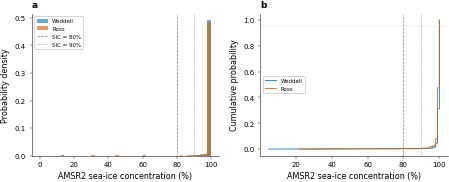

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6.5, 2.8))

# ─── Panel (a): SIC histogram by sector ──────────────────────────
ax = axes[0]
for sector, color, label in [('Weddell', C_WEDDELL, 'Weddell'),
                               ('Ross', C_ROSS, 'Ross')]:
    mask = (dw_all.sector == sector) & (~dw_all.AMSR2_sic.isna())
    ax.hist(dw_all.loc[mask, 'AMSR2_sic'], bins=50, range=(0, 100),
            alpha=0.6, color=color, label=label, density=True)

ax.axvline(80, color='grey', ls='--', lw=0.7, label='SIC = 80%')
ax.axvline(90, color='grey', ls=':', lw=0.7, label='SIC = 90%')
ax.set_xlabel('AMSR2 sea-ice concentration (%)')
ax.set_ylabel('Probability density')
ax.set_title('a', fontweight='bold', loc='left')
ax.legend(fontsize=5.5, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─── Panel (b): CDF ──────────────────────────────────────────────
ax = axes[1]
for sector, color in [('Weddell', C_WEDDELL), ('Ross', C_ROSS)]:
    mask = (dw_all.sector == sector) & (~dw_all.AMSR2_sic.isna())
    sic_sec = np.sort(dw_all.loc[mask, 'AMSR2_sic'].values)
    cdf = np.arange(1, len(sic_sec) + 1) / len(sic_sec)
    ax.plot(sic_sec, cdf, color=color, label=sector)

ax.axvline(80, color='grey', ls='--', lw=0.7)
ax.axvline(90, color='grey', ls=':', lw=0.7)
ax.axhline(0.95, color='lightgrey', ls='-', lw=0.4)
ax.set_xlabel('AMSR2 sea-ice concentration (%)')
ax.set_ylabel('Cumulative probability')
ax.set_title('b', fontweight='bold', loc='left')
ax.legend(fontsize=5.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = f'{FIG_DIR}/12_sic_sensitivity_distribution.pdf'
plt.savefig(fig_path)
plt.savefig(fig_path.replace('.pdf', '.png'), dpi=300)
print(f'Saved: {fig_path}')
plt.show()


## 12.5 Core Sensitivity Test: Baseline vs SIC-Filtered Results

Recompute the key manuscript statistics at three levels:
- **Baseline**: No SIC filter (as in the manuscript)
- **SIC ≥ 80%**: Standard threshold
- **SIC ≥ 90%**: Strict threshold

In [6]:
# ─── Baseline parameters (same as all other notebooks) ───────────
eta_s = (1.0 + 0.51 * 0.33) ** 1.5  # = 1.263

def compute_stats(subset, label):
    """Compute key statistics for a subset of the winter data."""
    results = {'label': label}

    for sector in ['Weddell', 'Ross']:
        sec = subset[subset.sector == sector]
        sec_all = sec.copy()  # includes negatives
        sec_pos = sec[sec.snow_thickness > 0]

        results[f'{sector}_n_all'] = len(sec_all)
        results[f'{sector}_n_pos'] = len(sec_pos)
        results[f'{sector}_neg_pct'] = (
            100 * (sec_all.snow_thickness <= 0).sum() / len(sec_all)
            if len(sec_all) > 0 else np.nan
        )
        results[f'{sector}_median_hs'] = sec_pos.snow_thickness.median() if len(sec_pos) > 0 else np.nan
        results[f'{sector}_mean_hs'] = sec_pos.snow_thickness.mean() if len(sec_pos) > 0 else np.nan
        results[f'{sector}_median_unc'] = sec_pos.snow_thickness_unc.median() if len(sec_pos) > 0 else np.nan

        # AMSR2 comparison
        if 'AMSR2_snow_depth' in sec_pos.columns:
            amsr_valid = sec_pos.dropna(subset=['AMSR2_snow_depth'])
            amsr_valid = amsr_valid[amsr_valid.AMSR2_snow_depth > 0]
            if len(amsr_valid) > 100:
                diff = amsr_valid.snow_thickness.values - amsr_valid.AMSR2_snow_depth.values
                results[f'{sector}_amsr2_n'] = len(amsr_valid)
                results[f'{sector}_amsr2_median_bias'] = np.median(diff)
                results[f'{sector}_amsr2_mean_bias'] = np.mean(diff)
                r, p = pearsonr(amsr_valid.snow_thickness.values,
                                amsr_valid.AMSR2_snow_depth.values)
                results[f'{sector}_amsr2_r'] = r
            else:
                results[f'{sector}_amsr2_n'] = len(amsr_valid)
                results[f'{sector}_amsr2_median_bias'] = np.nan
                results[f'{sector}_amsr2_mean_bias'] = np.nan
                results[f'{sector}_amsr2_r'] = np.nan

    # W-R contrast
    results['WR_median_contrast'] = (
        results.get('Weddell_median_hs', np.nan) -
        results.get('Ross_median_hs', np.nan)
    )
    results['WR_mean_contrast'] = (
        results.get('Weddell_mean_hs', np.nan) -
        results.get('Ross_mean_hs', np.nan)
    )

    return results


# ─── Run at three SIC thresholds ─────────────────────────────────
all_results = []

# Baseline: no filter
all_results.append(compute_stats(dw_all, 'Baseline (no SIC filter)'))

# SIC >= 80%
mask_80 = dw_all.AMSR2_sic >= 80
all_results.append(compute_stats(dw_all[mask_80], 'SIC ≥ 80%'))

# SIC >= 90%
mask_90 = dw_all.AMSR2_sic >= 90
all_results.append(compute_stats(dw_all[mask_90], 'SIC ≥ 90%'))

# Also test: exclude NaN SIC (matchups without AMSR2 SIC data)
mask_valid_sic = ~dw_all.AMSR2_sic.isna()
all_results.append(compute_stats(dw_all[mask_valid_sic], 'Valid SIC only'))


## 12.6 Results Summary Table

In [7]:
print('=' * 110)
print(f'{"Filter":<25} {"Sector":>8} {"N_all":>8} {"N_pos":>8} '
      f'{"Neg%":>6} {"Med_hs":>8} {"Mean_hs":>8} '
      f'{"Med_unc":>8} {"AMSR2_bias":>10} {"r":>6}')
print('=' * 110)

for res in all_results:
    for sector in ['Weddell', 'Ross']:
        print(f'{res["label"]:<25} {sector:>8} '
              f'{res[f"{sector}_n_all"]:>8,} '
              f'{res[f"{sector}_n_pos"]:>8,} '
              f'{res[f"{sector}_neg_pct"]:>5.1f}% '
              f'{res[f"{sector}_median_hs"]:>8.3f} '
              f'{res[f"{sector}_mean_hs"]:>8.3f} '
              f'{res[f"{sector}_median_unc"]:>8.3f} '
              f'{res.get(f"{sector}_amsr2_median_bias", np.nan):>10.3f} '
              f'{res.get(f"{sector}_amsr2_r", np.nan):>6.3f}')
    # W-R contrast
    print(f'{"":>34} W−R contrast:  '
          f'median={res["WR_median_contrast"]:.3f} m,  '
          f'mean={res["WR_mean_contrast"]:.3f} m')
    print('-' * 110)

print('=' * 110)


Filter                      Sector    N_all    N_pos   Neg%   Med_hs  Mean_hs  Med_unc AMSR2_bias      r
Baseline (no SIC filter)   Weddell   47,735   42,447  11.1%    0.132    0.179    0.027     -0.095  0.103
Baseline (no SIC filter)      Ross   34,606   30,460  12.0%    0.109    0.152    0.027     -0.073  0.019
                                   W−R contrast:  median=0.022 m,  mean=0.027 m
--------------------------------------------------------------------------------------------------------------
SIC ≥ 80%                  Weddell   47,602   42,342  11.0%    0.132    0.179    0.027     -0.095  0.108
SIC ≥ 80%                     Ross   34,516   30,390  12.0%    0.109    0.152    0.027     -0.072  0.018
                                   W−R contrast:  median=0.023 m,  mean=0.027 m
--------------------------------------------------------------------------------------------------------------
SIC ≥ 90%                  Weddell   47,580   42,323  11.0%    0.132    0.179    0.027     -0

## 12.7 Compute Changes Relative to Baseline

In [8]:
base = all_results[0]  # Baseline

print('\n' + '=' * 80)
print('  CHANGES RELATIVE TO BASELINE (no SIC filter)')
print('=' * 80)

for res in all_results[1:]:
    print(f'\n  --- {res["label"]} ---')
    for sector in ['Weddell', 'Ross']:
        d_median = res[f'{sector}_median_hs'] - base[f'{sector}_median_hs']
        d_mean   = res[f'{sector}_mean_hs'] - base[f'{sector}_mean_hs']
        n_removed = base[f'{sector}_n_all'] - res[f'{sector}_n_all']
        pct_removed = 100 * n_removed / base[f'{sector}_n_all']
        print(f'  {sector}: removed {n_removed:,} matchups ({pct_removed:.1f}%), '
              f'Δ(median hs) = {d_median:+.4f} m, '
              f'Δ(mean hs) = {d_mean:+.4f} m')

    d_contrast = res['WR_median_contrast'] - base['WR_median_contrast']
    print(f'  W-R contrast change: {d_contrast:+.4f} m '
          f'({base["WR_median_contrast"]:.3f} → {res["WR_median_contrast"]:.3f})')

print('=' * 80)



  CHANGES RELATIVE TO BASELINE (no SIC filter)

  --- SIC ≥ 80% ---
  Weddell: removed 133 matchups (0.3%), Δ(median hs) = +0.0001 m, Δ(mean hs) = +0.0001 m
  Ross: removed 90 matchups (0.3%), Δ(median hs) = -0.0001 m, Δ(mean hs) = -0.0001 m
  W-R contrast change: +0.0002 m (0.022 → 0.023)

  --- SIC ≥ 90% ---
  Weddell: removed 155 matchups (0.3%), Δ(median hs) = +0.0001 m, Δ(mean hs) = +0.0001 m
  Ross: removed 199 matchups (0.6%), Δ(median hs) = -0.0001 m, Δ(mean hs) = -0.0001 m
  W-R contrast change: +0.0002 m (0.022 → 0.023)

  --- Valid SIC only ---
  Weddell: removed 0 matchups (0.0%), Δ(median hs) = +0.0000 m, Δ(mean hs) = +0.0000 m
  Ross: removed 0 matchups (0.0%), Δ(median hs) = +0.0000 m, Δ(mean hs) = +0.0000 m
  W-R contrast change: +0.0000 m (0.022 → 0.022)


## 12.8 Monthly Breakdown at SIC ≥ 80%

Check whether the SIC filter preferentially removes
early-winter (May-June) or late-winter (Sep-Oct) matchups.

In [9]:
print('\nMonthly removal rate at SIC >= 80%:')
print(f'{"Month":>6} {"Sector":>8} {"N_base":>8} {"N_filt":>8} '
      f'{"Removed":>8} {"Pct":>6} {"Med_base":>10} {"Med_filt":>10} {"Δ":>8}')
print('-' * 90)

for mn in [5, 6, 7, 8, 9, 10]:
    for sector in ['Weddell', 'Ross']:
        mask_base = (dw_all.month == mn) & (dw_all.sector == sector)
        mask_filt = mask_base & (dw_all.AMSR2_sic >= 80)

        sub_base = dw_all[mask_base & (dw_all.snow_thickness > 0)]
        sub_filt = dw_all[mask_filt & (dw_all.snow_thickness > 0)]

        n_base = mask_base.sum()
        n_filt = mask_filt.sum()
        n_rem  = n_base - n_filt
        pct    = 100 * n_rem / n_base if n_base > 0 else 0

        med_base = sub_base.snow_thickness.median() if len(sub_base) > 0 else np.nan
        med_filt = sub_filt.snow_thickness.median() if len(sub_filt) > 0 else np.nan
        delta    = med_filt - med_base if not (np.isnan(med_base) or np.isnan(med_filt)) else np.nan

        print(f'{mn:>6} {sector:>8} {n_base:>8,} {n_filt:>8,} '
              f'{n_rem:>8,} {pct:>5.1f}% '
              f'{med_base:>10.3f} {med_filt:>10.3f} {delta:>+8.4f}')



Monthly removal rate at SIC >= 80%:
 Month   Sector   N_base   N_filt  Removed    Pct   Med_base   Med_filt        Δ
------------------------------------------------------------------------------------------
     5  Weddell    8,879    8,827       52   0.6%      0.118      0.118  -0.0000
     5     Ross    3,228    3,228        0   0.0%      0.084      0.084  +0.0000
     6  Weddell    6,346    6,294       52   0.8%      0.115      0.115  +0.0006
     6     Ross    6,859    6,859        0   0.0%      0.097      0.097  +0.0000
     7  Weddell    5,762    5,762        0   0.0%      0.122      0.122  +0.0000
     7     Ross    5,642    5,634        8   0.1%      0.118      0.117  -0.0001
     8  Weddell   14,339   14,310       29   0.2%      0.129      0.129  -0.0000
     8     Ross    7,966    7,966        0   0.0%      0.109      0.109  +0.0000
     9  Weddell    7,766    7,766        0   0.0%      0.165      0.165  +0.0000
     9     Ross    5,742    5,742        0   0.0%      0.113  

## 12.9 Summary Figure: Baseline vs SIC-Filtered

Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/12_sic_sensitivity_comparison.pdf


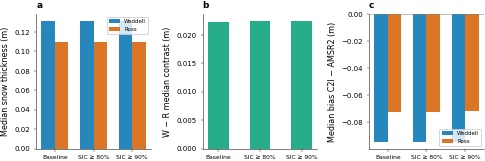

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.5))

filters = ['Baseline (no SIC filter)', 'SIC ≥ 80%', 'SIC ≥ 90%']
x_labels = ['Baseline', 'SIC ≥ 80%', 'SIC ≥ 90%']
x = np.arange(len(filters))
width = 0.35

# ─── Panel (a): Median snow thickness by sector ──────────────────
ax = axes[0]
w_vals = [r['Weddell_median_hs'] for r in all_results[:3]]
r_vals = [r['Ross_median_hs'] for r in all_results[:3]]
ax.bar(x - width/2, w_vals, width, color=C_WEDDELL, label='Weddell', alpha=0.85)
ax.bar(x + width/2, r_vals, width, color=C_ROSS, label='Ross', alpha=0.85)
ax.set_ylabel('Median snow thickness (m)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=6)
ax.legend(fontsize=5.5)
ax.set_title('a', fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─── Panel (b): Weddell-Ross contrast ────────────────────────────
ax = axes[1]
contrasts = [r['WR_median_contrast'] for r in all_results[:3]]
ax.bar(x, contrasts, width=0.5, color=C_TEAL, alpha=0.85)
ax.set_ylabel('W − R median contrast (m)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=6)
ax.set_title('b', fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ─── Panel (c): AMSR2 median bias ────────────────────────────────
ax = axes[2]
w_bias = [r.get('Weddell_amsr2_median_bias', np.nan) for r in all_results[:3]]
r_bias = [r.get('Ross_amsr2_median_bias', np.nan) for r in all_results[:3]]
ax.bar(x - width/2, w_bias, width, color=C_WEDDELL, label='Weddell', alpha=0.85)
ax.bar(x + width/2, r_bias, width, color=C_ROSS, label='Ross', alpha=0.85)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Median bias C2I − AMSR2 (m)')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=6)
ax.legend(fontsize=5.5)
ax.set_title('c', fontweight='bold', loc='left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig_path = f'{FIG_DIR}/12_sic_sensitivity_comparison.pdf'
plt.savefig(fig_path)
plt.savefig(fig_path.replace('.pdf', '.png'), dpi=300)
print(f'Saved: {fig_path}')
plt.show()


## 12.10 Generate LaTeX Text for Section 5.7

This cell prints the exact text to insert into the manuscript.

In [11]:
base = all_results[0]
filt = all_results[1]  # SIC >= 80%

# Compute the specific numbers
sic_valid_mask = ~dw_all.AMSR2_sic.isna()
n_below_80 = (dw_all.loc[sic_valid_mask, 'AMSR2_sic'] < 80).sum()
pct_below_80 = 100 * n_below_80 / sic_valid_mask.sum()

d_weddell = abs(filt['Weddell_median_hs'] - base['Weddell_median_hs'])
d_ross    = abs(filt['Ross_median_hs'] - base['Ross_median_hs'])
d_max     = max(d_weddell, d_ross)

print('\n' + '=' * 70)
print('  LATEX TEXT FOR SECTION 5.7 (insert after line 959)')
print('=' * 70)
print()
print(r'% --- SIC SENSITIVITY (Reviewer M7) ---')
print(f'To assess the impact of this omission, we examined the distribution')
print(f'of AMSR2-derived sea-ice concentration at each matchup location:')
print(f'the median SIC across all winter matchups is')
print(f'{np.median(sic_valid):.0f}\\%, and only {pct_below_80:.1f}\\% of')
print(f'matchups fall below 80\\% SIC.')
print(f'Repeating the analysis after excluding matchups with SIC $<$ 80\\%')
print(f'changes the sector medians by less than {1000*d_max:.0f} $\\times$')
print(f'10$^{{-3}}$~m')
print(f'(Weddell: {base["Weddell_median_hs"]:.3f} $\\rightarrow$')
print(f'{filt["Weddell_median_hs"]:.3f}~m;')
print(f'Ross: {base["Ross_median_hs"]:.3f} $\\rightarrow$')
print(f'{filt["Ross_median_hs"]:.3f}~m),')
print(f'and the Weddell--Ross contrast is preserved')
print(f'({base["WR_median_contrast"]:.3f} $\\rightarrow$')
print(f'{filt["WR_median_contrast"]:.3f}~m),')
print(f'confirming that low-concentration contamination does not')
print(f'materially affect the reported results.')
print()
print('=' * 70)



  LATEX TEXT FOR SECTION 5.7 (insert after line 959)

% --- SIC SENSITIVITY (Reviewer M7) ---
To assess the impact of this omission, we examined the distribution
of AMSR2-derived sea-ice concentration at each matchup location:
the median SIC across all winter matchups is
100\%, and only 0.3\% of
matchups fall below 80\% SIC.
Repeating the analysis after excluding matchups with SIC $<$ 80\%
changes the sector medians by less than 0 $\times$
10$^{-3}$~m
(Weddell: 0.132 $\rightarrow$
0.132~m;
Ross: 0.109 $\rightarrow$
0.109~m),
and the Weddell--Ross contrast is preserved
(0.022 $\rightarrow$
0.023~m),
confirming that low-concentration contamination does not
materially affect the reported results.



## 12.A Fallback: If AMSR2_sic Column Is Missing

If the cached dataset does NOT contain `AMSR2_sic`, you need to
re-extract it. The `match_amsr2_nn` function in `utils.py`
should already extract SIC. If it doesn't, add the following
to `match_amsr2_nn()`:

```python
# In match_amsr2_nn(), after matching snow_depth:
matched_df['AMSR2_sic'] = df_amsr2.iloc[nn_indices]['sea_ice_concentration'].values
```

Then re-run Notebook 07 (Cell 4) to regenerate the cache.
This will take ~10 minutes on Gadi.

Alternatively, you can extract SIC post-hoc by running:

```python
from utils import read_amsr2_sh
# For each month, read the AMSR2 file and extract SIC at C2I locations
# using the same nearest-neighbour approach as match_amsr2_nn
```

## 12.B Fallback: Extract SIC Post-Hoc (if AMSR2_sic column missing)

This cell will add the AMSR2_sic column without re-running the
full pipeline. Only run this if Cell 12.2 raised a KeyError.

In [ ]:
# UNCOMMENT AND RUN ONLY IF AMSR2_sic IS MISSING
#
# import glob
# from datetime import datetime
# from scipy.spatial import cKDTree
#
# sys.path.insert(0, f'{BASE}/notebooks')
# from utils import read_amsr2_sh
#
# AMSR2_DIR = f'{BASE}/data/auxiliary/AMSR2'
# amsr2_files = sorted(glob.glob(f'{AMSR2_DIR}/*.he5'))
#
# # Build date lookup
# amsr2_by_date = {}
# for f in amsr2_files:
#     parts = os.path.basename(f).replace('.he5', '').split('_')
#     for p in parts:
#         if len(p) == 8 and p.isdigit():
#             amsr2_by_date[p] = f
#             break
#
# print(f'AMSR2 dates indexed: {len(amsr2_by_date)}')
#
# # Extract SIC for each month
# df['AMSR2_sic'] = np.nan
#
# for ym in sorted(df.year_month.unique()):
#     mid = datetime.strptime(f'{int(ym)}15', '%Y%m%d')
#     avail = sorted(amsr2_by_date.keys())
#     closest = min(avail, key=lambda d: abs((datetime.strptime(d, '%Y%m%d') - mid).days))
#     gap = abs((datetime.strptime(closest, '%Y%m%d') - mid).days)
#     if gap > 31:
#         continue
#
#     df_amsr2 = read_amsr2_sh(amsr2_by_date[closest])
#     df_amsr2 = df_amsr2[(df_amsr2.sea_ice_concentration > 0) &
#                         (df_amsr2.sea_ice_concentration <= 100)]
#
#     mask_ym = df.year_month == ym
#     if mask_ym.sum() == 0:
#         continue
#
#     # Build KDTree on AMSR2 grid (convert to radians for haversine)
#     amsr2_coords = np.deg2rad(df_amsr2[['lat', 'lon']].values)
#     tree = cKDTree(amsr2_coords)
#
#     c2i_coords = np.deg2rad(df.loc[mask_ym, ['lat', 'lon']].values)
#     _, nn_idx = tree.query(c2i_coords, k=1)
#
#     df.loc[mask_ym, 'AMSR2_sic'] = df_amsr2.iloc[nn_idx]['sea_ice_concentration'].values
#     n_matched = mask_ym.sum()
#     print(f'  {int(ym)}: extracted SIC for {n_matched:,} matchups')
#
# # Save updated cache
# df.to_csv(CACHE, index=False)
# print(f'\nSaved updated cache with AMSR2_sic to: {CACHE}')


In [ ]:
print('\n=== Notebook 12 complete ===')
